# Student Performance EDA

This notebook explores score patterns, risk factors, and feature relationships used by the ML pipeline.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "student_data.csv").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "student_data.csv"
df = pd.read_csv(DATA_PATH)

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## Dataset Overview

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

In [3]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [4]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

## Final Score Distribution

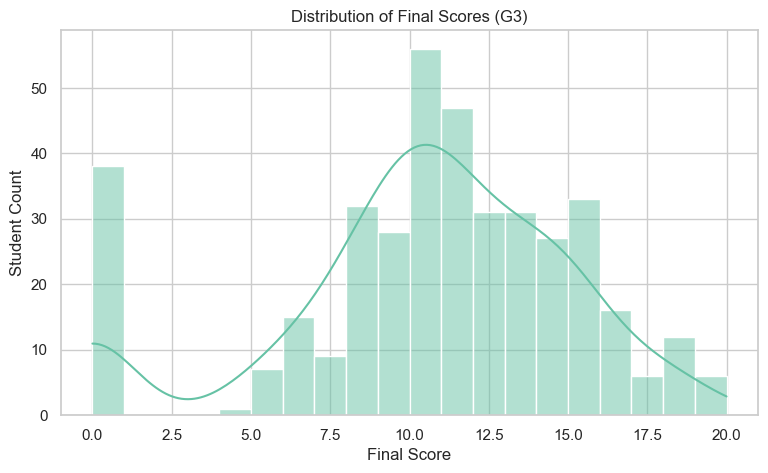

In [5]:
plt.figure(figsize=(9, 5))
sns.histplot(df["G3"], bins=20, kde=True)
plt.title("Distribution of Final Scores (G3)")
plt.xlabel("Final Score")
plt.ylabel("Student Count")
plt.show()

## Study Time vs Final Score

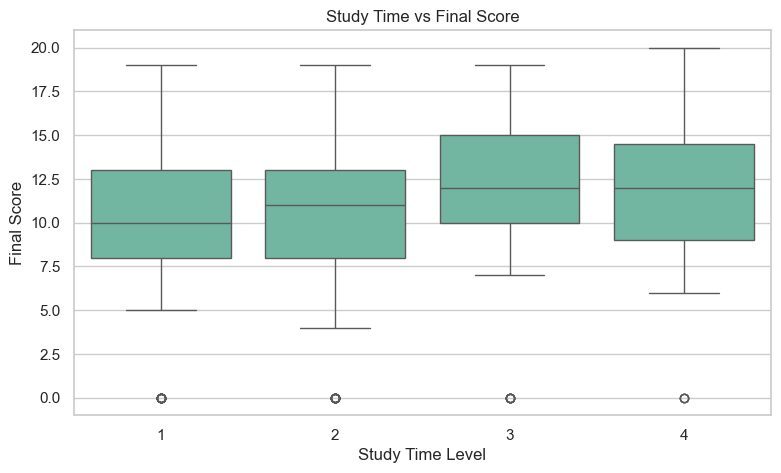

In [6]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="studytime", y="G3")
plt.title("Study Time vs Final Score")
plt.xlabel("Study Time Level")
plt.ylabel("Final Score")
plt.show()

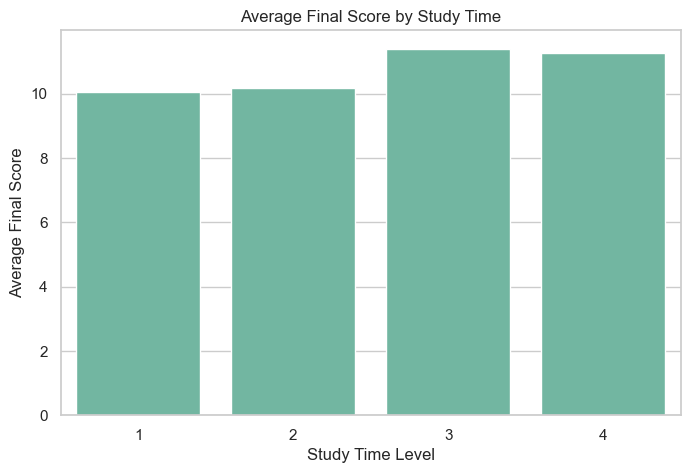

In [7]:
study_score = df.groupby("studytime", as_index=False)["G3"].mean()

plt.figure(figsize=(8, 5))
sns.barplot(data=study_score, x="studytime", y="G3")
plt.title("Average Final Score by Study Time")
plt.xlabel("Study Time Level")
plt.ylabel("Average Final Score")
plt.show()

## Failures Impact

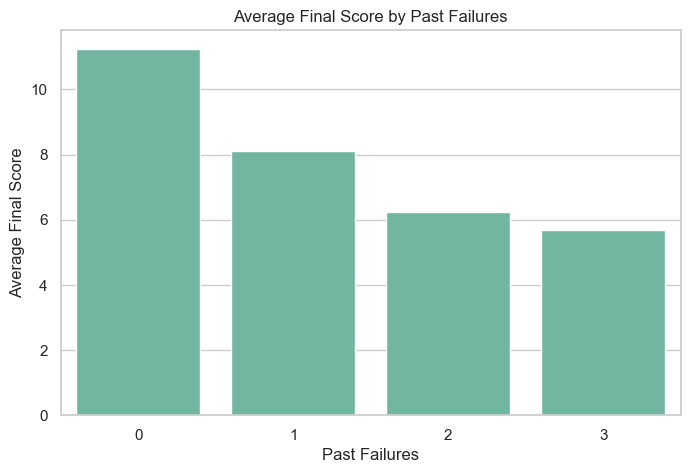

In [8]:
failures_score = df.groupby("failures", as_index=False)["G3"].mean()

plt.figure(figsize=(8, 5))
sns.barplot(data=failures_score, x="failures", y="G3")
plt.title("Average Final Score by Past Failures")
plt.xlabel("Past Failures")
plt.ylabel("Average Final Score")
plt.show()

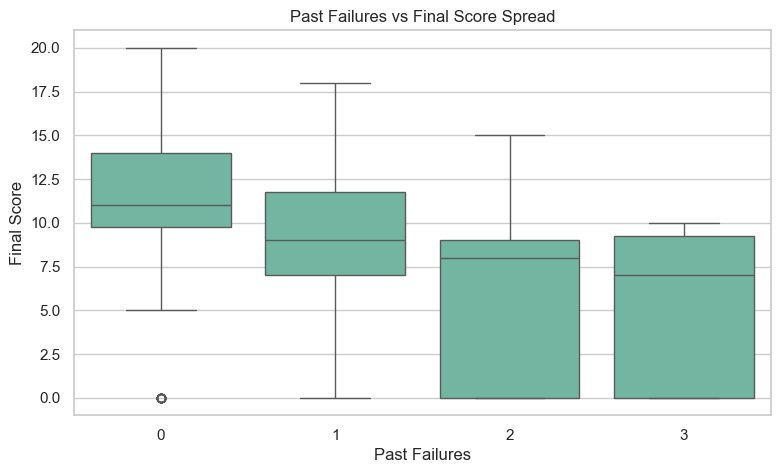

In [9]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="failures", y="G3")
plt.title("Past Failures vs Final Score Spread")
plt.xlabel("Past Failures")
plt.ylabel("Final Score")
plt.show()

## Absences Impact

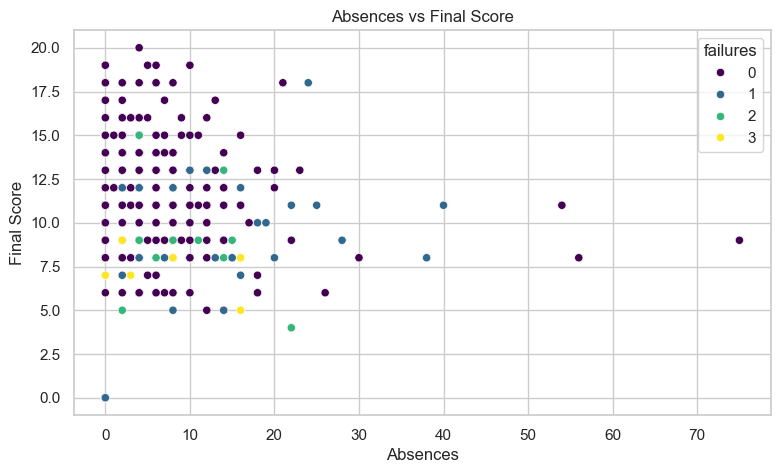

In [10]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x="absences", y="G3", hue="failures", palette="viridis")
plt.title("Absences vs Final Score")
plt.xlabel("Absences")
plt.ylabel("Final Score")
plt.show()

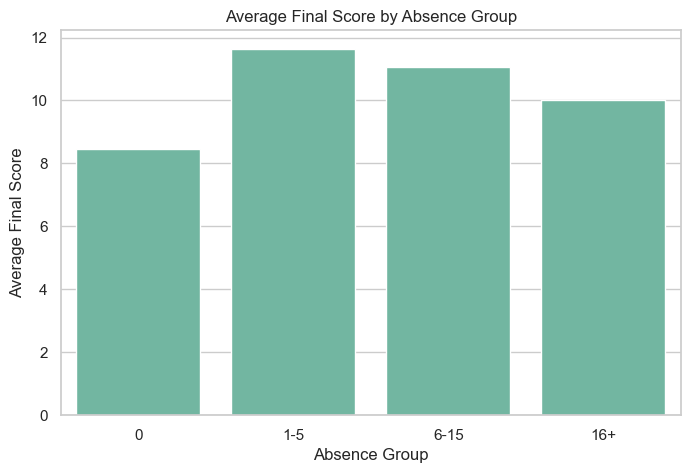

In [11]:
df["absence_group"] = pd.cut(
    df["absences"],
    bins=[-1, 0, 5, 15, df["absences"].max()],
    labels=["0", "1-5", "6-15", "16+"],
)
absence_score = df.groupby("absence_group", observed=False)["G3"].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=absence_score, x="absence_group", y="G3")
plt.title("Average Final Score by Absence Group")
plt.xlabel("Absence Group")
plt.ylabel("Average Final Score")
plt.show()

## Prior Grades vs Final Score

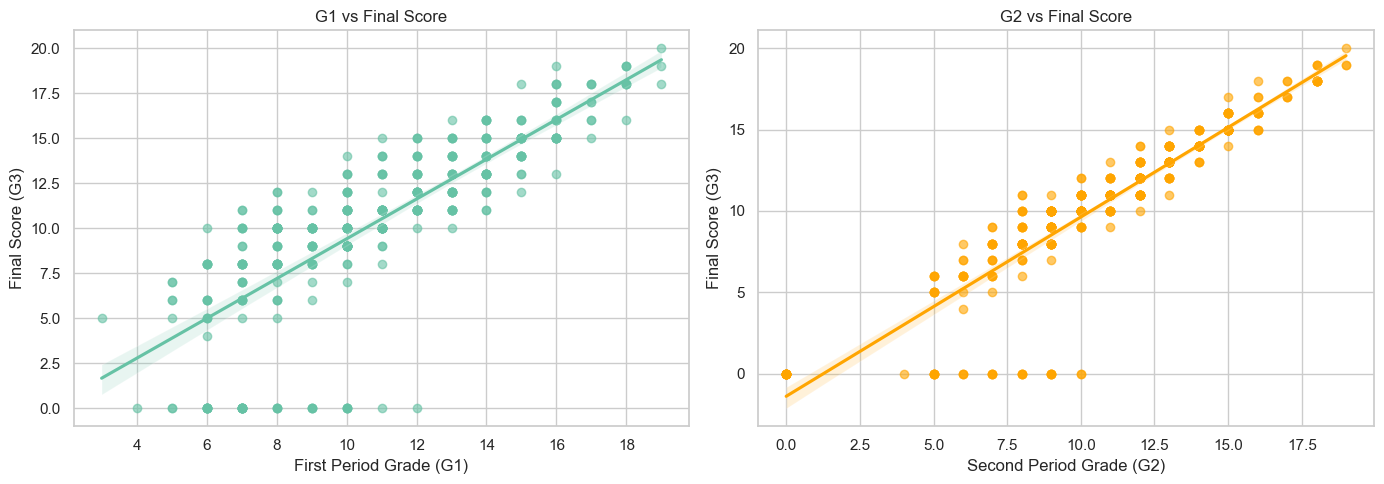

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(data=df, x="G1", y="G3", ax=axes[0], scatter_kws={"alpha": 0.6})
axes[0].set_title("G1 vs Final Score")
axes[0].set_xlabel("First Period Grade (G1)")
axes[0].set_ylabel("Final Score (G3)")

sns.regplot(data=df, x="G2", y="G3", ax=axes[1], scatter_kws={"alpha": 0.6}, color="orange")
axes[1].set_title("G2 vs Final Score")
axes[1].set_xlabel("Second Period Grade (G2)")
axes[1].set_ylabel("Final Score (G3)")

plt.tight_layout()
plt.show()

## Student Risk Distribution

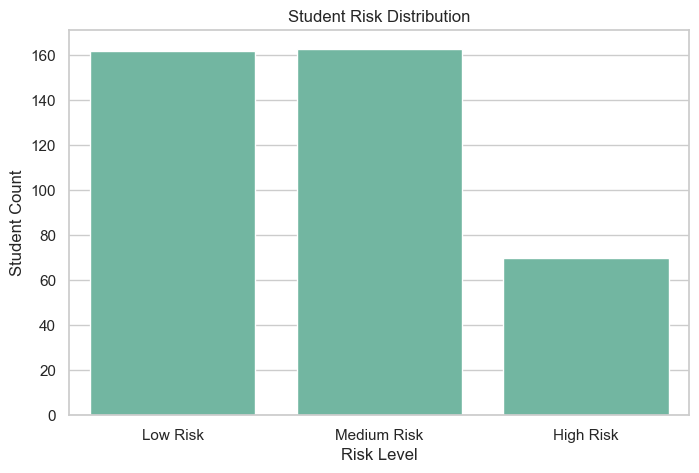

In [13]:
def risk_bucket(score):
    if score < 8:
        return "High Risk"
    if score < 12:
        return "Medium Risk"
    return "Low Risk"

df["risk_level"] = df["G3"].apply(risk_bucket)
risk_order = ["Low Risk", "Medium Risk", "High Risk"]

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="risk_level", order=risk_order)
plt.title("Student Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Student Count")
plt.show()

## Support And Activity Factors

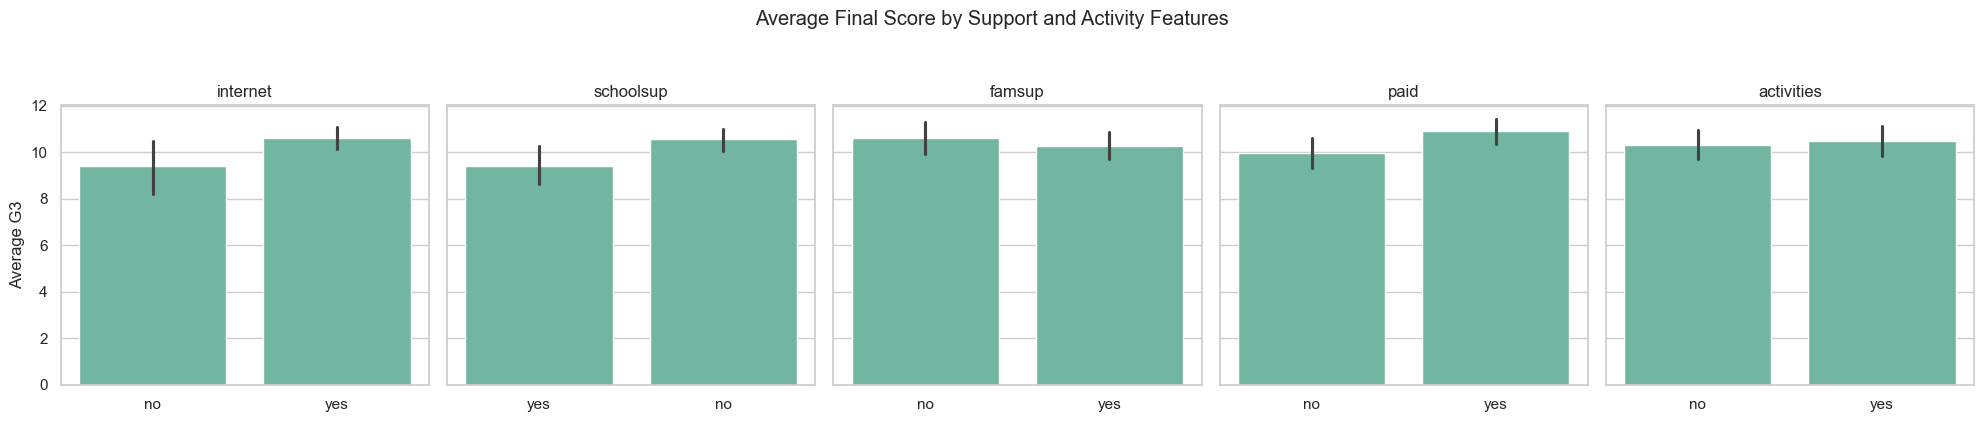

In [14]:
support_features = ["internet", "schoolsup", "famsup", "paid", "activities"]
fig, axes = plt.subplots(1, len(support_features), figsize=(20, 4), sharey=True)

for ax, feature in zip(axes, support_features):
    sns.barplot(data=df, x=feature, y="G3", ax=ax)
    ax.set_title(feature)
    ax.set_xlabel("")
    ax.set_ylabel("Average G3" if feature == support_features[0] else "")

plt.suptitle("Average Final Score by Support and Activity Features", y=1.05)
plt.tight_layout()
plt.show()

## Family And Health Factors

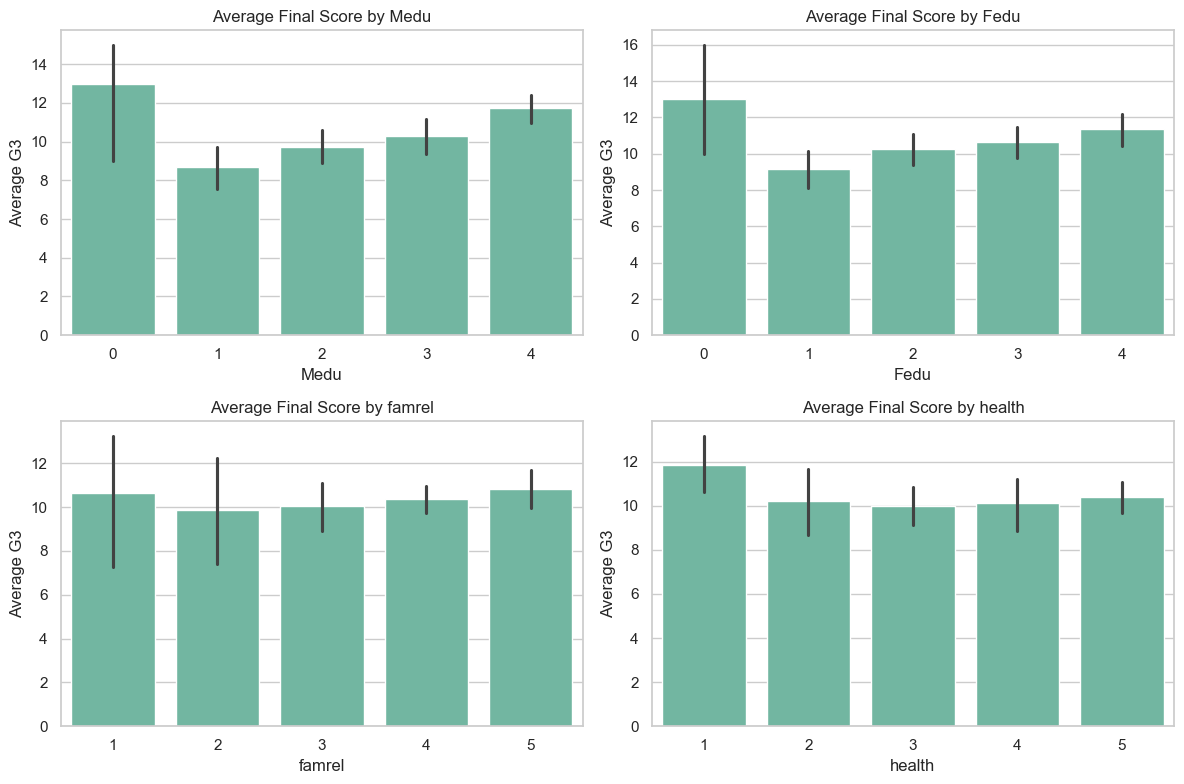

In [15]:
family_health_features = ["Medu", "Fedu", "famrel", "health"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, feature in zip(axes, family_health_features):
    sns.barplot(data=df, x=feature, y="G3", ax=ax)
    ax.set_title(f"Average Final Score by {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Average G3")

plt.tight_layout()
plt.show()

## Feature Correlation Heatmap

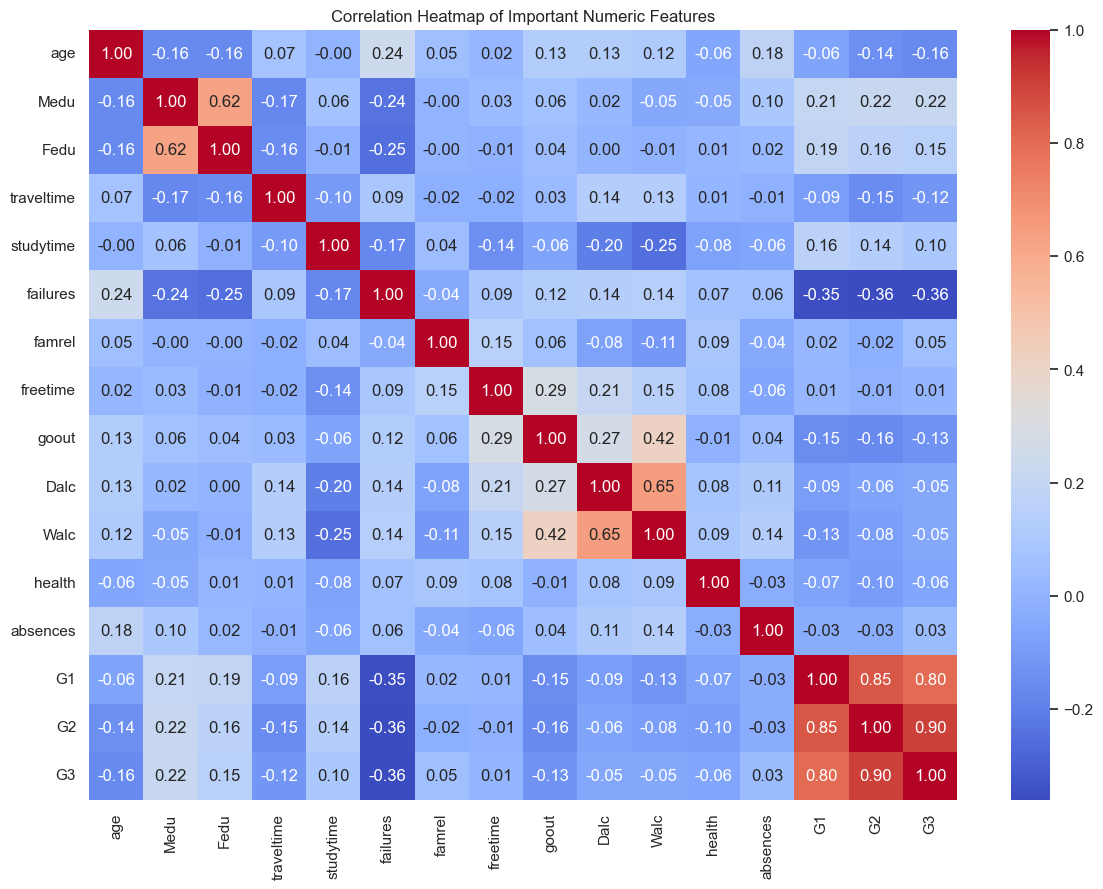

In [16]:
important_numeric = [
    "age", "Medu", "Fedu", "traveltime", "studytime", "failures",
    "famrel", "freetime", "goout", "Dalc", "Walc", "health",
    "absences", "G1", "G2", "G3",
]

plt.figure(figsize=(14, 10))
sns.heatmap(df[important_numeric].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Important Numeric Features")
plt.show()